# Plotting the Wheeler Hendon diagram=>

### Seeing my mjo csv file

In [1]:
import pandas as pd
import numpy as np

CSV_PATH = "D:\PHD 2025~\PHD\MJO_Index_1.csv"   # <-- change this to your file path

df = pd.read_csv(CSV_PATH)

print("=" * 50)
print("COLUMN NAMES:")
print(df.columns.tolist())

print("\nSHAPE (rows, columns):", df.shape)

print("\nFIRST 5 ROWS:")
print(df.head())

print("\nDATA TYPES:")
print(df.dtypes)

print("\nBASIC STATISTICS:")
print(df.describe())

print("\nMISSING VALUES PER COLUMN:")
print(df.isnull().sum())
print("=" * 50)

<>:4: SyntaxWarning: invalid escape sequence '\P'
<>:4: SyntaxWarning: invalid escape sequence '\P'
C:\Users\hp\AppData\Local\Temp\ipykernel_17260\3238161368.py:4: SyntaxWarning: invalid escape sequence '\P'
  CSV_PATH = "D:\PHD 2025~\PHD\MJO_Index_1.csv"   # <-- change this to your file path


COLUMN NAMES:
['year', 'month', 'day', 'RMM1', 'RMM2', 'phase', 'amplitude']

SHAPE (rows, columns): (1612, 7)

FIRST 5 ROWS:
   year  month  day      RMM1     RMM2  phase  amplitude
0  1974     10    1  0.578932 -0.90974    3.0   1.078330
1  1974     10    2  0.758947 -0.95044    3.0   1.216280
2  1974     10    3  0.896649 -0.58042    4.0   1.068120
3  1974     10    4  0.673576 -0.38633    4.0   0.776501
4  1974     10    5  0.632136 -0.10522    4.0   0.640834

DATA TYPES:
year           int64
month          int64
day            int64
RMM1         float64
RMM2         float64
phase        float64
amplitude    float64
dtype: object

BASIC STATISTICS:
              year   month          day          RMM1          RMM2  \
count  1612.000000  1612.0  1612.000000  1.612000e+03  1.612000e+03   
mean   1999.500000    10.0    16.000000  1.923077e+34  1.923077e+34   
std      15.012988     0.0     8.947047  1.373778e+35  1.373778e+35   
min    1974.000000    10.0     1.000000 -3.082914e+00 -

# Plotting the Wheeler Hendon diagram

<>:24: SyntaxWarning: invalid escape sequence '\P'
<>:24: SyntaxWarning: invalid escape sequence '\P'
C:\Users\hp\AppData\Local\Temp\ipykernel_17260\2626832456.py:24: SyntaxWarning: invalid escape sequence '\P'
  CSV_PATH = "D:\PHD 2025~\PHD\MJO_Index_1.csv"   # <-- change to your path


Days available for Oct 2025: 31
 day      RMM1      RMM2  phase  amplitude
   1 -0.590416 -1.128623    2.0   1.273727
   2 -0.469483 -1.083206    2.0   1.180571
   3 -0.366929 -0.855299    2.0   0.930684
   4 -0.172869 -0.504192    2.0   0.533004
   5 -0.091652 -0.080213    1.0   0.121796
   6 -0.056785  0.260449    7.0   0.266568
   7 -0.249311  0.298812    7.0   0.389159
   8 -0.459578  0.273325    8.0   0.534713
   9 -0.638201  0.081854    8.0   0.643429
  10 -0.745940 -0.052371    1.0   0.747776
  11 -0.872539 -0.085825    1.0   0.876750
  12 -1.230686 -0.207122    1.0   1.247993
  13 -1.287949 -0.373380    1.0   1.340979
  14 -1.425023 -0.656664    1.0   1.569044
  15 -1.218123 -1.092595    1.0   1.636334
  16 -1.029146 -1.269802    2.0   1.634484
  17 -0.898242 -1.334497    2.0   1.608639
  18 -0.327911 -1.523365    2.0   1.558258
  19  0.167375 -1.753045    3.0   1.761017
  20  0.604909 -1.748895    3.0   1.850553
  21  1.086946 -1.583456    3.0   1.920621
  22  1.567763 -1.3020

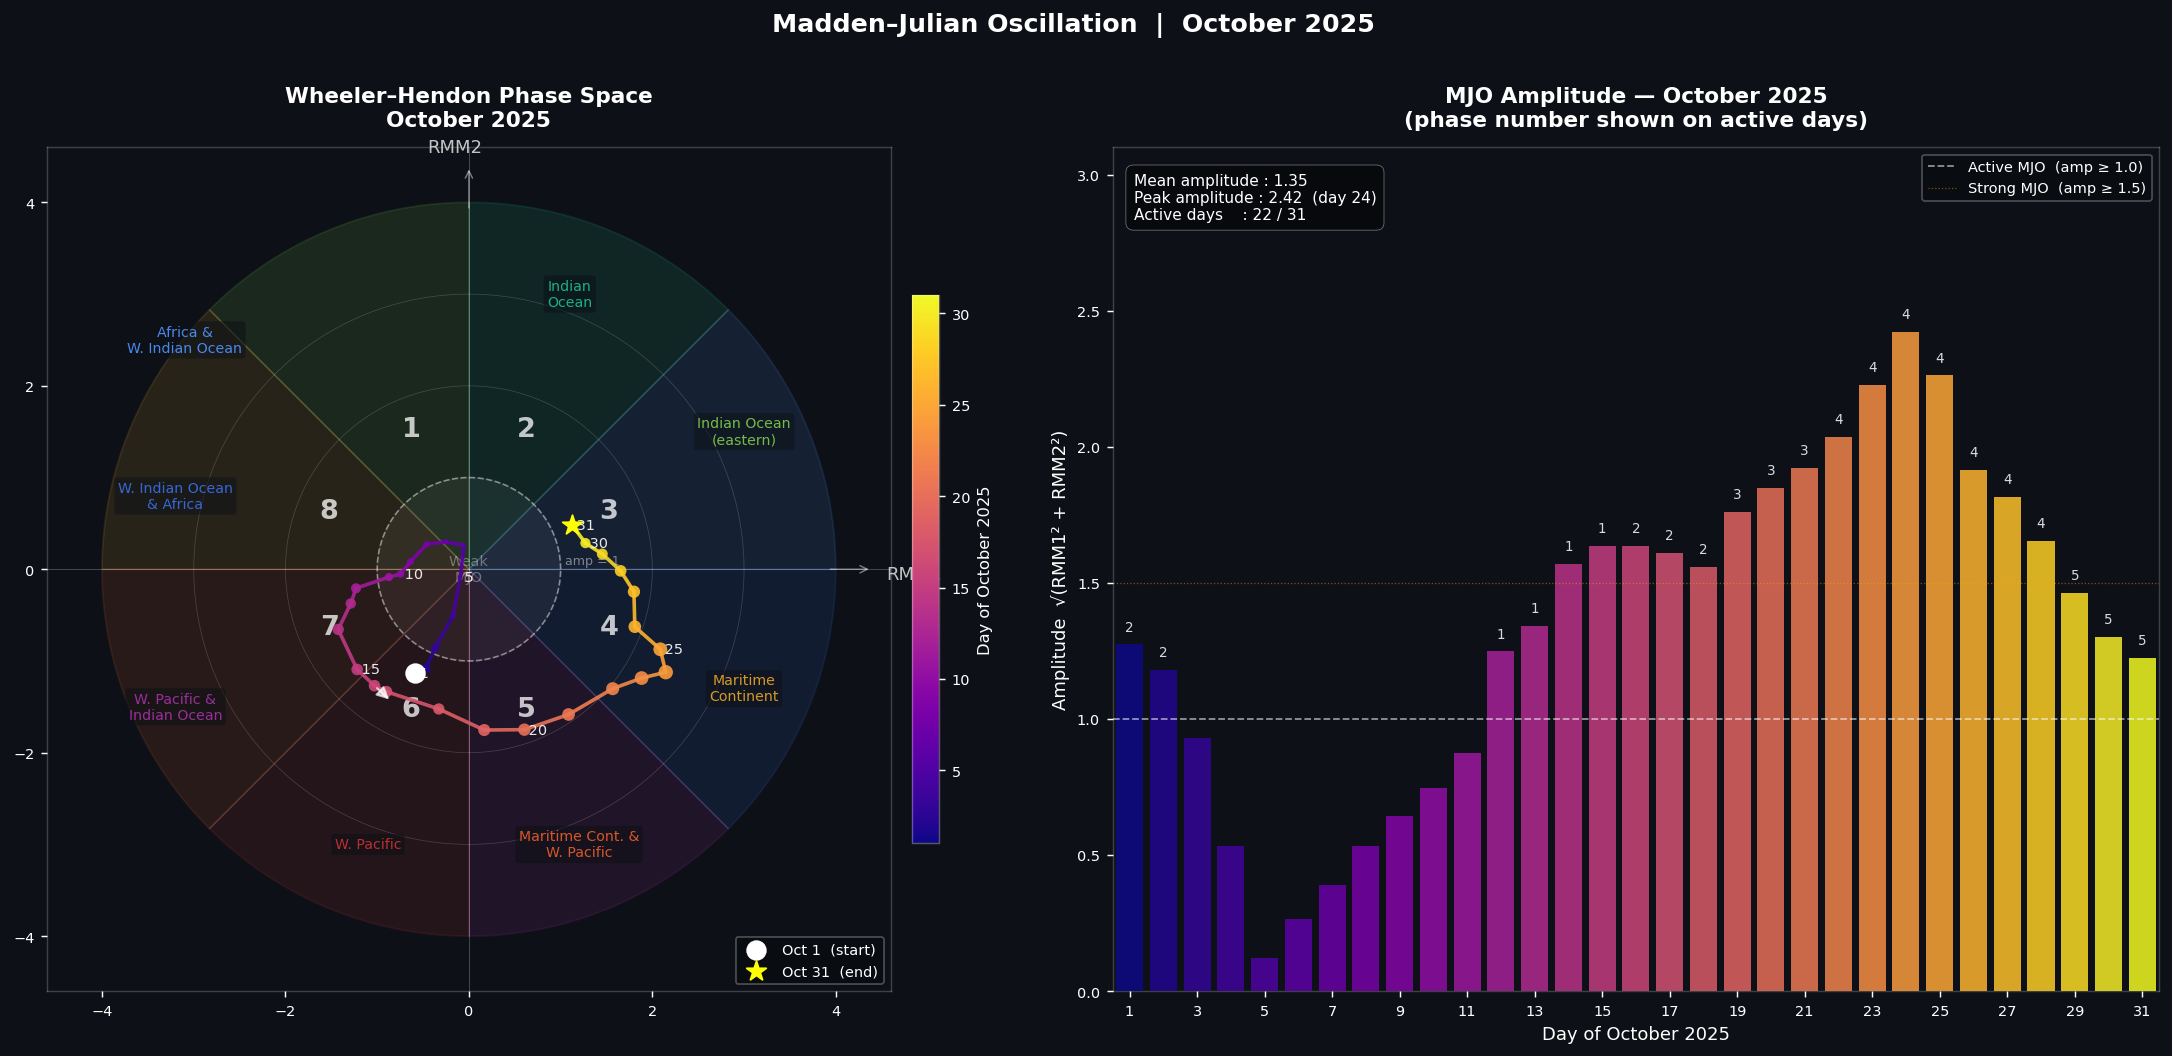

Saved → MJO_WH_October2025.png


In [2]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   Wheeler-Hendon RMM Phase Space Diagram — October 2025     ║
# ║   For Jupyter Notebook (.ipynb)                             ║
# ╚══════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────
# CELL 1 — Imports
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.collections import LineCollection

%matplotlib inline
plt.rcParams["figure.dpi"] = 130


# ─────────────────────────────────────────────
# CELL 2 — Load & Clean Data
# ─────────────────────────────────────────────
CSV_PATH = "D:\PHD 2025~\PHD\MJO_Index_1.csv"   # <-- change to your path

df = pd.read_csv(CSV_PATH)

# The BOM dataset uses 999.000 as a fill/missing value.
# Replace any value > 100 with NaN (RMM values are always between ~-4 and 4)
df["RMM1"]      = df["RMM1"].where(df["RMM1"].abs() < 100, np.nan)
df["RMM2"]      = df["RMM2"].where(df["RMM2"].abs() < 100, np.nan)
df["amplitude"] = df["amplitude"].where(df["amplitude"] < 100, np.nan)

# Filter to October 2025 only
oct2025 = df[(df["year"] == 2025) & (df["month"] == 10)].copy()
oct2025 = oct2025.dropna(subset=["RMM1", "RMM2"])
oct2025 = oct2025.sort_values("day").reset_index(drop=True)

print(f"Days available for Oct 2025: {len(oct2025)}")
print(oct2025[["day", "RMM1", "RMM2", "phase", "amplitude"]].to_string(index=False))


# ─────────────────────────────────────────────
# CELL 3 — Helper: Build the WH Background
# ─────────────────────────────────────────────
def draw_wh_background(ax):
    """
    Draws the standard Wheeler-Hendon phase space background:
      - 8 shaded sectors with phase numbers
      - Amplitude rings at 1.0 and 2.0
      - Axis lines and geographic labels
    Everything is drawn in dark style.
    """

    ax.set_facecolor("#0d1117")

    # ── Sector colours (one per phase) ──────────────────────────
    sector_colors = [
        "#4C8EF5",   # Phase 1 — Africa / W. Indian Ocean  (blue)
        "#1DB88A",   # Phase 2 — Indian Ocean              (teal)
        "#7BC44C",   # Phase 3 — Indian Ocean (eastern)    (green)
        "#E0A025",   # Phase 4 — Maritime Continent        (amber)
        "#E05A2B",   # Phase 5 — Maritime Cont. / W. Pac.  (orange)
        "#C43030",   # Phase 6 — W. Pacific                (red)
        "#A030A0",   # Phase 7 — W. Pacific / Indian Ocean (purple)
        "#3A6AE0",   # Phase 8 — W. Indian Ocean / Africa  (blue-violet)
    ]

    # Geographic labels: (text, x, y)
    geo_labels = [
        ("Africa &\nW. Indian Ocean",   -3.1,  2.5),
        ("Indian\nOcean",                1.1,  3.0),
        ("Indian Ocean\n(eastern)",      3.0,  1.5),
        ("Maritime\nContinent",          3.0, -1.3),
        ("Maritime Cont. &\nW. Pacific", 1.2, -3.0),
        ("W. Pacific",                  -1.1, -3.0),
        ("W. Pacific &\nIndian Ocean",  -3.2, -1.5),
        ("W. Indian Ocean\n& Africa",   -3.2,  0.8),
    ]

    # Phase number positions (at r=1.65, centre of each 45° wedge)
    # Wedge centres (degrees): 112.5, 67.5, 22.5, 337.5, 292.5, 247.5, 202.5, 157.5
    wedge_centres_deg = [112.5, 67.5, 22.5, 337.5, 292.5, 247.5, 202.5, 157.5]

    r_outer = 4.0
    r_num   = 1.65    # radius for phase number labels

    for i in range(8):
        # ── Sector shading ──
        a0 = np.radians(i * 45)
        a1 = np.radians((i + 1) * 45)
        theta = np.linspace(a0, a1, 60)
        x_fill = np.concatenate([[0], r_outer * np.cos(theta), [0]])
        y_fill = np.concatenate([[0], r_outer * np.sin(theta), [0]])
        ax.fill(x_fill, y_fill, color=sector_colors[i], alpha=0.13, zorder=1)

        # ── Sector dividing lines ──
        ax.plot([0, r_outer * np.cos(a0)],
                [0, r_outer * np.sin(a0)],
                color="white", lw=0.4, alpha=0.18, zorder=2)

        # ── Phase number ──
        ang = np.radians(wedge_centres_deg[i])
        ax.text(r_num * np.cos(ang), r_num * np.sin(ang),
                str(i + 1),
                color="white", fontsize=15, fontweight="bold",
                ha="center", va="center", alpha=0.75, zorder=4)

        # ── Geographic label ──
        txt, lx, ly = geo_labels[i]
        ax.text(lx, ly, txt,
                color=sector_colors[i], fontsize=7.8,
                ha="center", va="center", alpha=0.95,
                fontweight="500", zorder=4,
                bbox=dict(boxstyle="round,pad=0.25",
                          facecolor="#0d1117", alpha=0.55,
                          edgecolor="none"))

    # ── Amplitude rings ──
    theta = np.linspace(0, 2 * np.pi, 360)
    # r = 1 : dashed white (active MJO threshold)
    ax.plot(np.cos(theta), np.sin(theta),
            color="white", lw=0.9, ls="--", alpha=0.45, zorder=3)
    ax.text(1.05, 0.06, "amp = 1",
            color="white", fontsize=7, alpha=0.45)
    # r = 2 : thin solid
    ax.plot(2 * np.cos(theta), 2 * np.sin(theta),
            color="white", lw=0.4, ls="-", alpha=0.18, zorder=3)
    # r = 3 : thin solid
    ax.plot(3 * np.cos(theta), 3 * np.sin(theta),
            color="white", lw=0.4, ls="-", alpha=0.18, zorder=3)

    # ── Weak MJO inner zone ──
    weak = plt.Circle((0, 0), 1.0, color="white", alpha=0.05, zorder=1)
    ax.add_patch(weak)
    ax.text(0, 0, "Weak\nMJO", color="white", fontsize=8, alpha=0.35,
            ha="center", va="center", zorder=3)

    # ── Axis lines ──
    ax.axhline(0, color="white", lw=0.5, alpha=0.25, zorder=2)
    ax.axvline(0, color="white", lw=0.5, alpha=0.25, zorder=2)

    # Axis arrow tips
    ax.annotate("", xy=(4.4, 0), xytext=(3.9, 0),
                arrowprops=dict(arrowstyle="->", color="white",
                                lw=0.8, alpha=0.45))
    ax.annotate("", xy=(0, 4.4), xytext=(0, 3.9),
                arrowprops=dict(arrowstyle="->", color="white",
                                lw=0.8, alpha=0.45))
    ax.text( 4.55, -0.05, "RMM1", color="white", fontsize=10,
             va="center", alpha=0.75)
    ax.text(-0.15,  4.55, "RMM2", color="white", fontsize=10,
             ha="center", alpha=0.75)

    # ── Axes limits ──
    ax.set_xlim(-4.6, 4.6)
    ax.set_ylim(-4.6, 4.6)
    ax.set_aspect("equal")
    ax.tick_params(colors="white", labelsize=8)
    for spine in ax.spines.values():
        spine.set_color("white")
        spine.set_alpha(0.2)


# ─────────────────────────────────────────────
# CELL 4 — Plot: Wheeler-Hendon Phase Diagram
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 8))
fig.patch.set_facecolor("#0d1117")

rmm1 = oct2025["RMM1"].values
rmm2 = oct2025["RMM2"].values
amp  = oct2025["amplitude"].values
days = oct2025["day"].values

# ── Left panel: Phase space ──────────────────
ax = axes[0]
draw_wh_background(ax)

# Colour trajectory by day (plasma: early=purple, late=yellow)
cmap = plt.cm.plasma
norm = Normalize(vmin=1, vmax=31)

# Draw trajectory as coloured line segments
points   = np.array([rmm1, rmm2]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
seg_days = (days[:-1] + days[1:]) / 2          # midpoint day for colour
lc = LineCollection(segments, cmap=cmap, norm=norm,
                    linewidth=2.0, alpha=0.9, zorder=5,
                    capstyle="round", joinstyle="round")
lc.set_array(seg_days)
ax.add_collection(lc)

# Scatter dots (size reflects amplitude)
sc = ax.scatter(rmm1, rmm2,
                c=days, cmap=cmap, norm=norm,
                s=(np.clip(amp, 0, 4) * 18) ** 1.1,
                zorder=6, edgecolors="none", alpha=0.9)

# Day-number annotations (every 5 days + day 1 + last day)
label_days = set([1, days[-1]] + list(range(5, 32, 5)))
for i, (d, r1, r2) in enumerate(zip(days, rmm1, rmm2)):
    if d in label_days:
        ax.annotate(f" {int(d)}",
                    (r1, r2),
                    color="white", fontsize=8, alpha=0.9,
                    va="center", zorder=7,
                    fontweight="500")

# Start marker (white circle) and end marker (star)
ax.scatter(rmm1[0],  rmm2[0],  s=90, color="white",  zorder=8,
           marker="o", linewidths=1.8,
           edgecolors="white", label="Oct 1  (start)")
ax.scatter(rmm1[-1], rmm2[-1], s=130, color="yellow", zorder=8,
           marker="*", label=f"Oct {int(days[-1])}  (end)")

# Direction arrow at midpoint
mid = len(rmm1) // 2
dx  = rmm1[mid] - rmm1[mid - 1]
dy  = rmm2[mid] - rmm2[mid - 1]
ax.annotate("",
            xy=(rmm1[mid] + dx, rmm2[mid] + dy),
            xytext=(rmm1[mid], rmm2[mid]),
            arrowprops=dict(arrowstyle="-|>", color="white",
                            lw=1.2, mutation_scale=14, alpha=0.7),
            zorder=9)

# Colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.65, pad=0.02)
cbar.set_label("Day of October 2025", color="white", fontsize=9)
cbar.ax.yaxis.set_tick_params(color="white", labelcolor="white", labelsize=8)
cbar.outline.set_edgecolor("white")
cbar.outline.set_alpha(0.3)

# Legend & title
legend = ax.legend(loc="lower right", framealpha=0.25,
                   labelcolor="white", fontsize=8, facecolor="black",
                   edgecolor="white")
ax.set_title("Wheeler–Hendon Phase Space\nOctober 2025",
             color="white", fontsize=12, fontweight="bold", pad=12)


# ── Right panel: Amplitude time series ──────
ax2 = axes[1]
ax2.set_facecolor("#0d1117")

bar_colors = [cmap(norm(d)) for d in days]
ax2.bar(days, amp, color=bar_colors, width=0.8, alpha=0.85, zorder=3)

# Threshold lines
ax2.axhline(1.0, color="white",  lw=1.0, ls="--", alpha=0.55, zorder=4,
            label="Active MJO  (amp ≥ 1.0)")
ax2.axhline(1.5, color="orange", lw=0.7, ls=":",  alpha=0.45, zorder=4,
            label="Strong MJO  (amp ≥ 1.5)")

# Phase number above each active-day bar
for d, a, ph in zip(days, amp, oct2025["phase"].values):
    if a > 1.0 and not np.isnan(ph):
        ax2.text(d, a + 0.04, str(int(ph)),
                 ha="center", va="bottom",
                 color="white", fontsize=7.5, alpha=0.85)

# Stats box (top-left)
active  = int((amp > 1.0).sum())
mean_a  = amp.mean()
max_day = int(days[np.argmax(amp)])
max_a   = amp.max()
stats   = (f"Mean amplitude : {mean_a:.2f}\n"
           f"Peak amplitude : {max_a:.2f}  (day {max_day})\n"
           f"Active days    : {active} / {len(days)}")
ax2.text(0.02, 0.97, stats,
         transform=ax2.transAxes,
         color="white", fontsize=8.5, va="top",
         bbox=dict(boxstyle="round,pad=0.5",
                   facecolor="black", alpha=0.45,
                   edgecolor="white", linewidth=0.4))

ax2.set_xlabel("Day of October 2025", color="white", fontsize=10)
ax2.set_ylabel("Amplitude  √(RMM1² + RMM2²)", color="white", fontsize=10)
ax2.set_title("MJO Amplitude — October 2025\n(phase number shown on active days)",
              color="white", fontsize=12, fontweight="bold", pad=12)
ax2.set_xticks(range(1, 32, 2))
ax2.set_xlim(0.5, 31.5)
ax2.set_ylim(0, max(amp) * 1.28)
ax2.tick_params(colors="white", labelsize=8)
for spine in ax2.spines.values():
    spine.set_color("white")
    spine.set_alpha(0.2)
legend2 = ax2.legend(loc="upper right", framealpha=0.25,
                     labelcolor="white", fontsize=8,
                     facecolor="black", edgecolor="white")

fig.suptitle("Madden–Julian Oscillation  |  October 2025",
             color="white", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("MJO_WH_October2025.png", dpi=150,
            bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("Saved → MJO_WH_October2025.png")

## Modifying the plot=>

<>:23: SyntaxWarning: invalid escape sequence '\P'
<>:23: SyntaxWarning: invalid escape sequence '\P'
C:\Users\hp\AppData\Local\Temp\ipykernel_17260\42168053.py:23: SyntaxWarning: invalid escape sequence '\P'
  CSV_PATH = "D:\PHD 2025~\PHD\MJO_Unfiltered_1980-2025.csv"   # <-- change to your file path


Plotting 61 days  |  2025-09-01 → 2025-10-31
      date      RMM1      RMM2  phase  amplitude
2025-09-01  0.037445 -0.048646    3.0   0.061389
2025-09-02 -0.211677 -0.381196    2.0   0.436025
2025-09-03 -0.498393 -0.587402    2.0   0.770349
2025-09-04 -0.435898 -0.781930    2.0   0.895222
2025-09-05 -0.129672 -0.983117    2.0   0.991632
2025-09-06 -0.199285 -1.344374    2.0   1.359064
2025-09-07 -0.252063 -1.460830    2.0   1.482417
2025-09-08 -0.034009 -1.292576    2.0   1.293024
2025-09-09  0.214558 -1.051887    3.0   1.073546
2025-09-10  0.321545 -0.831266    3.0   0.891288
2025-09-11  0.401973 -0.593376    3.0   0.716713
2025-09-12  0.314050 -0.349710    3.0   0.470026
2025-09-13 -0.019469 -0.180283    2.0   0.181331
2025-09-14 -0.392129 -0.043265    1.0   0.394508
2025-09-15 -0.780557  0.117142    8.0   0.789298
2025-09-16 -0.846644  0.190490    8.0   0.867809
2025-09-17 -0.633701  0.066366    8.0   0.637166
2025-09-18 -0.763150 -0.113495    1.0   0.771543
2025-09-19 -0.681480  0.

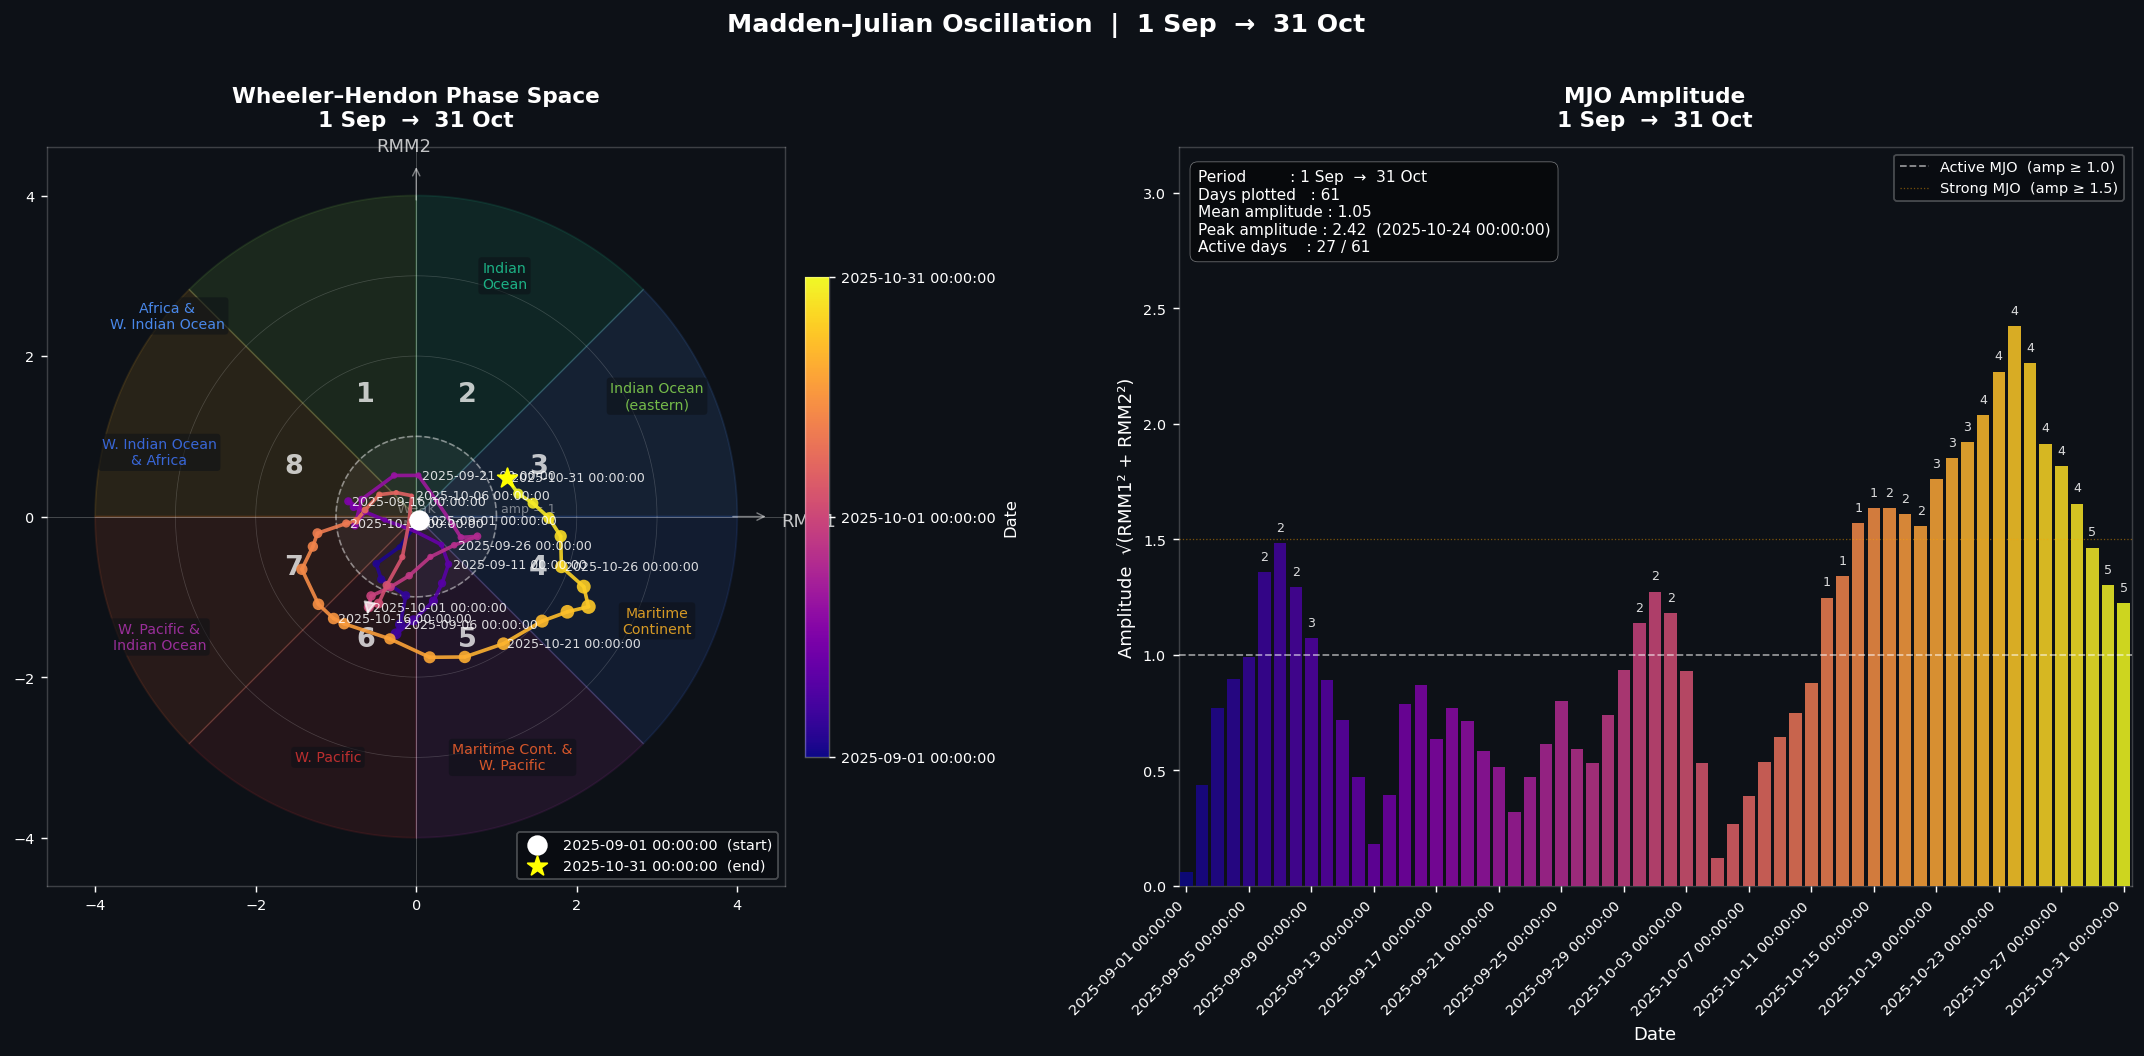

Saved → MJO_WH_20250901_20251031.png


In [8]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   Wheeler-Hendon RMM Phase Space Diagram — Custom Date Range ║
# ║   For Jupyter Notebook (.ipynb)                             ║
# ╚══════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────
# CELL 1 — Imports
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.collections import LineCollection

%matplotlib inline
plt.rcParams["figure.dpi"] = 130


# ─────────────────────────────────────────────
# CELL 2 — ✏️ SET YOUR DATE RANGE HERE
# ─────────────────────────────────────────────
CSV_PATH = "D:\PHD 2025~\PHD\MJO_Unfiltered_1980-2025.csv"   # <-- change to your file path

START_DATE = "2025-09-01"    # format: "YYYY-MM-DD"
END_DATE   = "2025-10-31"    # format: "YYYY-MM-DD"


# ─────────────────────────────────────────────
# CELL 3 — Load, Clean & Filter
# ─────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)

# Replace BOM missing value (999) with NaN
df["RMM1"]      = df["RMM1"].where(df["RMM1"].abs() < 100, np.nan)
df["RMM2"]      = df["RMM2"].where(df["RMM2"].abs() < 100, np.nan)
df["amplitude"] = df["amplitude"].where(df["amplitude"] < 100, np.nan)

# Build a proper datetime column for easy filtering
df["date"] = pd.to_datetime(df[["year", "month", "day"]])

# Parse user-supplied dates
start = pd.to_datetime(START_DATE)
end   = pd.to_datetime(END_DATE)

# Validate
if start > end:
    raise ValueError(f"START_DATE ({START_DATE}) must be before END_DATE ({END_DATE})")
if start < df["date"].min() or end > df["date"].max():
    raise ValueError(
        f"Date range {START_DATE} → {END_DATE} is outside the dataset.\n"
        f"Available range: {df['date'].min().date()} → {df['date'].max().date()}"
    )

# Filter
mask   = (df["date"] >= start) & (df["date"] <= end)
subset = df[mask].dropna(subset=["RMM1", "RMM2", "amplitude"])
subset = subset.sort_values("date").reset_index(drop=True)

# Nice date labels for each row (used in annotations)
subset["label"] = subset["date"].dt.strftime("%-d %b")   # e.g. "1 Oct"

print(f"Plotting {len(subset)} days  |  {start.date()} → {end.date()}")
print(subset[["date", "RMM1", "RMM2", "phase", "amplitude"]].to_string(index=False))


# ─────────────────────────────────────────────
# CELL 4 — Helper: WH Background
# ─────────────────────────────────────────────
def draw_wh_background(ax):
    ax.set_facecolor("#0d1117")

    sector_colors = [
        "#4C8EF5",  # Phase 1
        "#1DB88A",  # Phase 2
        "#7BC44C",  # Phase 3
        "#E0A025",  # Phase 4
        "#E05A2B",  # Phase 5
        "#C43030",  # Phase 6
        "#A030A0",  # Phase 7
        "#3A6AE0",  # Phase 8
    ]

    geo_labels = [
        ("Africa &\nW. Indian Ocean",    -3.1,  2.5),
        ("Indian\nOcean",                 1.1,  3.0),
        ("Indian Ocean\n(eastern)",       3.0,  1.5),
        ("Maritime\nContinent",           3.0, -1.3),
        ("Maritime Cont. &\nW. Pacific",  1.2, -3.0),
        ("W. Pacific",                   -1.1, -3.0),
        ("W. Pacific &\nIndian Ocean",   -3.2, -1.5),
        ("W. Indian Ocean\n& Africa",    -3.2,  0.8),
    ]

    wedge_centres_deg = [112.5, 67.5, 22.5, 337.5, 292.5, 247.5, 202.5, 157.5]
    r_outer = 4.0

    for i in range(8):
        a0 = np.radians(i * 45)
        a1 = np.radians((i + 1) * 45)
        theta   = np.linspace(a0, a1, 60)
        x_fill  = np.concatenate([[0], r_outer * np.cos(theta), [0]])
        y_fill  = np.concatenate([[0], r_outer * np.sin(theta), [0]])
        ax.fill(x_fill, y_fill, color=sector_colors[i], alpha=0.13, zorder=1)
        ax.plot([0, r_outer * np.cos(a0)],
                [0, r_outer * np.sin(a0)],
                color="white", lw=0.4, alpha=0.18, zorder=2)

        ang = np.radians(wedge_centres_deg[i])
        ax.text(1.65 * np.cos(ang), 1.65 * np.sin(ang), str(i + 1),
                color="white", fontsize=15, fontweight="bold",
                ha="center", va="center", alpha=0.75, zorder=4)

        txt, lx, ly = geo_labels[i]
        ax.text(lx, ly, txt,
                color=sector_colors[i], fontsize=7.8,
                ha="center", va="center", alpha=0.95,
                fontweight="500", zorder=4,
                bbox=dict(boxstyle="round,pad=0.25", facecolor="#0d1117",
                          alpha=0.55, edgecolor="none"))

    theta = np.linspace(0, 2 * np.pi, 360)
    ax.plot(np.cos(theta), np.sin(theta),
            color="white", lw=0.9, ls="--", alpha=0.45, zorder=3)
    ax.text(1.05, 0.06, "amp = 1", color="white", fontsize=7, alpha=0.45)
    for r in [2.0, 3.0]:
        ax.plot(r * np.cos(theta), r * np.sin(theta),
                color="white", lw=0.4, alpha=0.18, zorder=3)

    ax.add_patch(plt.Circle((0, 0), 1.0, color="white", alpha=0.05, zorder=1))
    ax.text(0, 0, "Weak\nMJO", color="white", fontsize=8, alpha=0.35,
            ha="center", va="center", zorder=3)

    ax.axhline(0, color="white", lw=0.5, alpha=0.25, zorder=2)
    ax.axvline(0, color="white", lw=0.5, alpha=0.25, zorder=2)
    ax.annotate("", xy=(4.4, 0), xytext=(3.9, 0),
                arrowprops=dict(arrowstyle="->", color="white", lw=0.8, alpha=0.45))
    ax.annotate("", xy=(0, 4.4), xytext=(0, 3.9),
                arrowprops=dict(arrowstyle="->", color="white", lw=0.8, alpha=0.45))
    ax.text( 4.55, -0.05, "RMM1", color="white", fontsize=10, va="center", alpha=0.75)
    ax.text(-0.15,  4.55, "RMM2", color="white", fontsize=10, ha="center", alpha=0.75)

    ax.set_xlim(-4.6, 4.6)
    ax.set_ylim(-4.6, 4.6)
    ax.set_aspect("equal")
    ax.tick_params(colors="white", labelsize=8)
    for spine in ax.spines.values():
        spine.set_color("white")
        spine.set_alpha(0.2)


# ─────────────────────────────────────────────
# CELL 5 — Plot
# ─────────────────────────────────────────────
rmm1   = subset["RMM1"].values
rmm2   = subset["RMM2"].values
amp    = subset["amplitude"].values
phases = subset["phase"].values
dates  = subset["date"].values          # numpy datetime64
labels = subset["label"].values         # "1 Oct", "2 Oct", ...
n      = len(subset)

# Map each row to a 0-1 value for colouring (position along the date range)
color_vals = np.linspace(0, 1, n)
cmap       = plt.cm.plasma
norm       = Normalize(vmin=0, vmax=1)

title_str  = f"{start.strftime("%d %b").lstrip("0") }  →  {end.strftime("%d %b").lstrip("0") }"

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
fig.patch.set_facecolor("#0d1117")


# ── LEFT: Phase space ────────────────────────
ax = axes[0]
draw_wh_background(ax)

# Coloured trajectory
points   = np.array([rmm1, rmm2]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
seg_cv   = (color_vals[:-1] + color_vals[1:]) / 2
lc = LineCollection(segments, cmap=cmap, norm=norm,
                    linewidth=2.0, alpha=0.9, zorder=5,
                    capstyle="round", joinstyle="round")
lc.set_array(seg_cv)
ax.add_collection(lc)

# Scatter dots (size ∝ amplitude)
ax.scatter(rmm1, rmm2,
           c=color_vals, cmap=cmap, norm=norm,
           s=(np.clip(amp, 0, 4) * 18) ** 1.1,
           zorder=6, edgecolors="none", alpha=0.9)

# ── Date annotations ──
# For short ranges (≤ 31 days): label every day
# For medium ranges (32–90 days): label every 5th day
# For long ranges (> 90 days): label every 15th day
if n <= 31:
    step = 1
elif n <= 90:
    step = 5
else:
    step = 15

for i in range(n):
    if i % step == 0 or i == n - 1:
        ax.annotate(f" {labels[i]}",
                    (rmm1[i], rmm2[i]),
                    color="white", fontsize=7, alpha=0.85,
                    va="center", zorder=7, fontweight="500")

# Start & end markers
ax.scatter(rmm1[0],  rmm2[0],  s=90,  color="white",  zorder=8,
           marker="o", edgecolors="white", linewidths=1.8,
           label=f"{labels[0]}  (start)")
ax.scatter(rmm1[-1], rmm2[-1], s=130, color="yellow", zorder=8,
           marker="*", label=f"{labels[-1]}  (end)")

# Direction arrow at midpoint
if n >= 3:
    mid = n // 2
    dx  = rmm1[mid] - rmm1[mid - 1]
    dy  = rmm2[mid] - rmm2[mid - 1]
    ax.annotate("",
                xy=(rmm1[mid] + dx, rmm2[mid] + dy),
                xytext=(rmm1[mid], rmm2[mid]),
                arrowprops=dict(arrowstyle="-|>", color="white",
                                lw=1.2, mutation_scale=14, alpha=0.7),
                zorder=9)

# Colorbar mapped to actual dates
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.65, pad=0.02)
cbar.set_label("Date", color="white", fontsize=9)
# Tick at start, middle, end
cbar.set_ticks([0, 0.5, 1.0])
cbar.set_ticklabels([labels[0], labels[n // 2], labels[-1]])
cbar.ax.yaxis.set_tick_params(color="white", labelcolor="white", labelsize=8)
cbar.outline.set_edgecolor("white")
cbar.outline.set_alpha(0.3)

ax.legend(loc="lower right", framealpha=0.25, labelcolor="white",
          fontsize=8, facecolor="black", edgecolor="white")
ax.set_title(f"Wheeler–Hendon Phase Space\n{title_str}",
             color="white", fontsize=12, fontweight="bold", pad=12)


# ── RIGHT: Amplitude time series ─────────────
ax2 = axes[1]
ax2.set_facecolor("#0d1117")

bar_colors = [cmap(norm(cv)) for cv in color_vals]
ax2.bar(range(n), amp, color=bar_colors, width=0.8, alpha=0.85, zorder=3)

# Threshold lines
ax2.axhline(1.0, color="white",  lw=1.0, ls="--", alpha=0.55, zorder=4,
            label="Active MJO  (amp ≥ 1.0)")
ax2.axhline(1.5, color="orange", lw=0.7, ls=":",  alpha=0.45, zorder=4,
            label="Strong MJO  (amp ≥ 1.5)")

# Phase number above active bars
for i, (a, ph) in enumerate(zip(amp, phases)):
    if a > 1.0 and not np.isnan(ph):
        ax2.text(i, a + 0.04, str(int(ph)),
                 ha="center", va="bottom",
                 color="white", fontsize=7, alpha=0.85)

# X-axis ticks: show dates, auto-spaced to avoid crowding
tick_step = max(1, n // 15)          # never show more than ~15 ticks
tick_idx  = list(range(0, n, tick_step))
if n - 1 not in tick_idx:
    tick_idx.append(n - 1)
ax2.set_xticks(tick_idx)
ax2.set_xticklabels([labels[i] for i in tick_idx],
                    rotation=45, ha="right", fontsize=7.5)

# Stats box
active  = int((amp > 1.0).sum())
mean_a  = amp.mean()
max_idx = np.argmax(amp)
stats   = (f"Period         : {title_str}\n"
           f"Days plotted   : {n}\n"
           f"Mean amplitude : {mean_a:.2f}\n"
           f"Peak amplitude : {amp[max_idx]:.2f}  ({labels[max_idx]})\n"
           f"Active days    : {active} / {n}")
ax2.text(0.02, 0.97, stats,
         transform=ax2.transAxes,
         color="white", fontsize=8.5, va="top",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="black",
                   alpha=0.45, edgecolor="white", linewidth=0.4))

ax2.set_xlim(-0.5, n - 0.5)
ax2.set_ylim(0, max(amp) * 1.32)
ax2.set_xlabel("Date", color="white", fontsize=10)
ax2.set_ylabel("Amplitude  √(RMM1² + RMM2²)", color="white", fontsize=10)
ax2.set_title(f"MJO Amplitude\n{title_str}",
              color="white", fontsize=12, fontweight="bold", pad=12)
ax2.tick_params(colors="white", labelsize=8)
for spine in ax2.spines.values():
    spine.set_color("white")
    spine.set_alpha(0.2)
ax2.legend(loc="upper right", framealpha=0.25, labelcolor="white",
           fontsize=8, facecolor="black", edgecolor="white")

fig.suptitle(f"Madden–Julian Oscillation  |  {title_str}",
             color="white", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()

fname = f"MJO_WH_{start.strftime('%Y%m%d')}_{end.strftime('%Y%m%d')}.png"
plt.savefig(fname, dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print(f"Saved → {fname}")

# MJO SEP - DEC =>

<>:24: SyntaxWarning: invalid escape sequence '\P'
<>:24: SyntaxWarning: invalid escape sequence '\P'
C:\Users\hp\AppData\Local\Temp\ipykernel_17260\538353125.py:24: SyntaxWarning: invalid escape sequence '\P'
  CSV_PATH = "D:\PHD 2025~\PHD\MJO_Unfiltered_1980-2025.csv"   # <-- change to your file path


Plotting 122 days  |  2025-09-01 → 2025-12-31
      date      RMM1      RMM2  phase  amplitude
2025-09-01  0.037445 -0.048646    3.0   0.061389
2025-09-02 -0.211677 -0.381196    2.0   0.436025
2025-09-03 -0.498393 -0.587402    2.0   0.770349
2025-09-04 -0.435898 -0.781930    2.0   0.895222
2025-09-05 -0.129672 -0.983117    2.0   0.991632
2025-09-06 -0.199285 -1.344374    2.0   1.359064
2025-09-07 -0.252063 -1.460830    2.0   1.482417
2025-09-08 -0.034009 -1.292576    2.0   1.293024
2025-09-09  0.214558 -1.051887    3.0   1.073546
2025-09-10  0.321545 -0.831266    3.0   0.891288
2025-09-11  0.401973 -0.593376    3.0   0.716713
2025-09-12  0.314050 -0.349710    3.0   0.470026
2025-09-13 -0.019469 -0.180283    2.0   0.181331
2025-09-14 -0.392129 -0.043265    1.0   0.394508
2025-09-15 -0.780557  0.117142    8.0   0.789298
2025-09-16 -0.846644  0.190490    8.0   0.867809
2025-09-17 -0.633701  0.066366    8.0   0.637166
2025-09-18 -0.763150 -0.113495    1.0   0.771543
2025-09-19 -0.681480  0

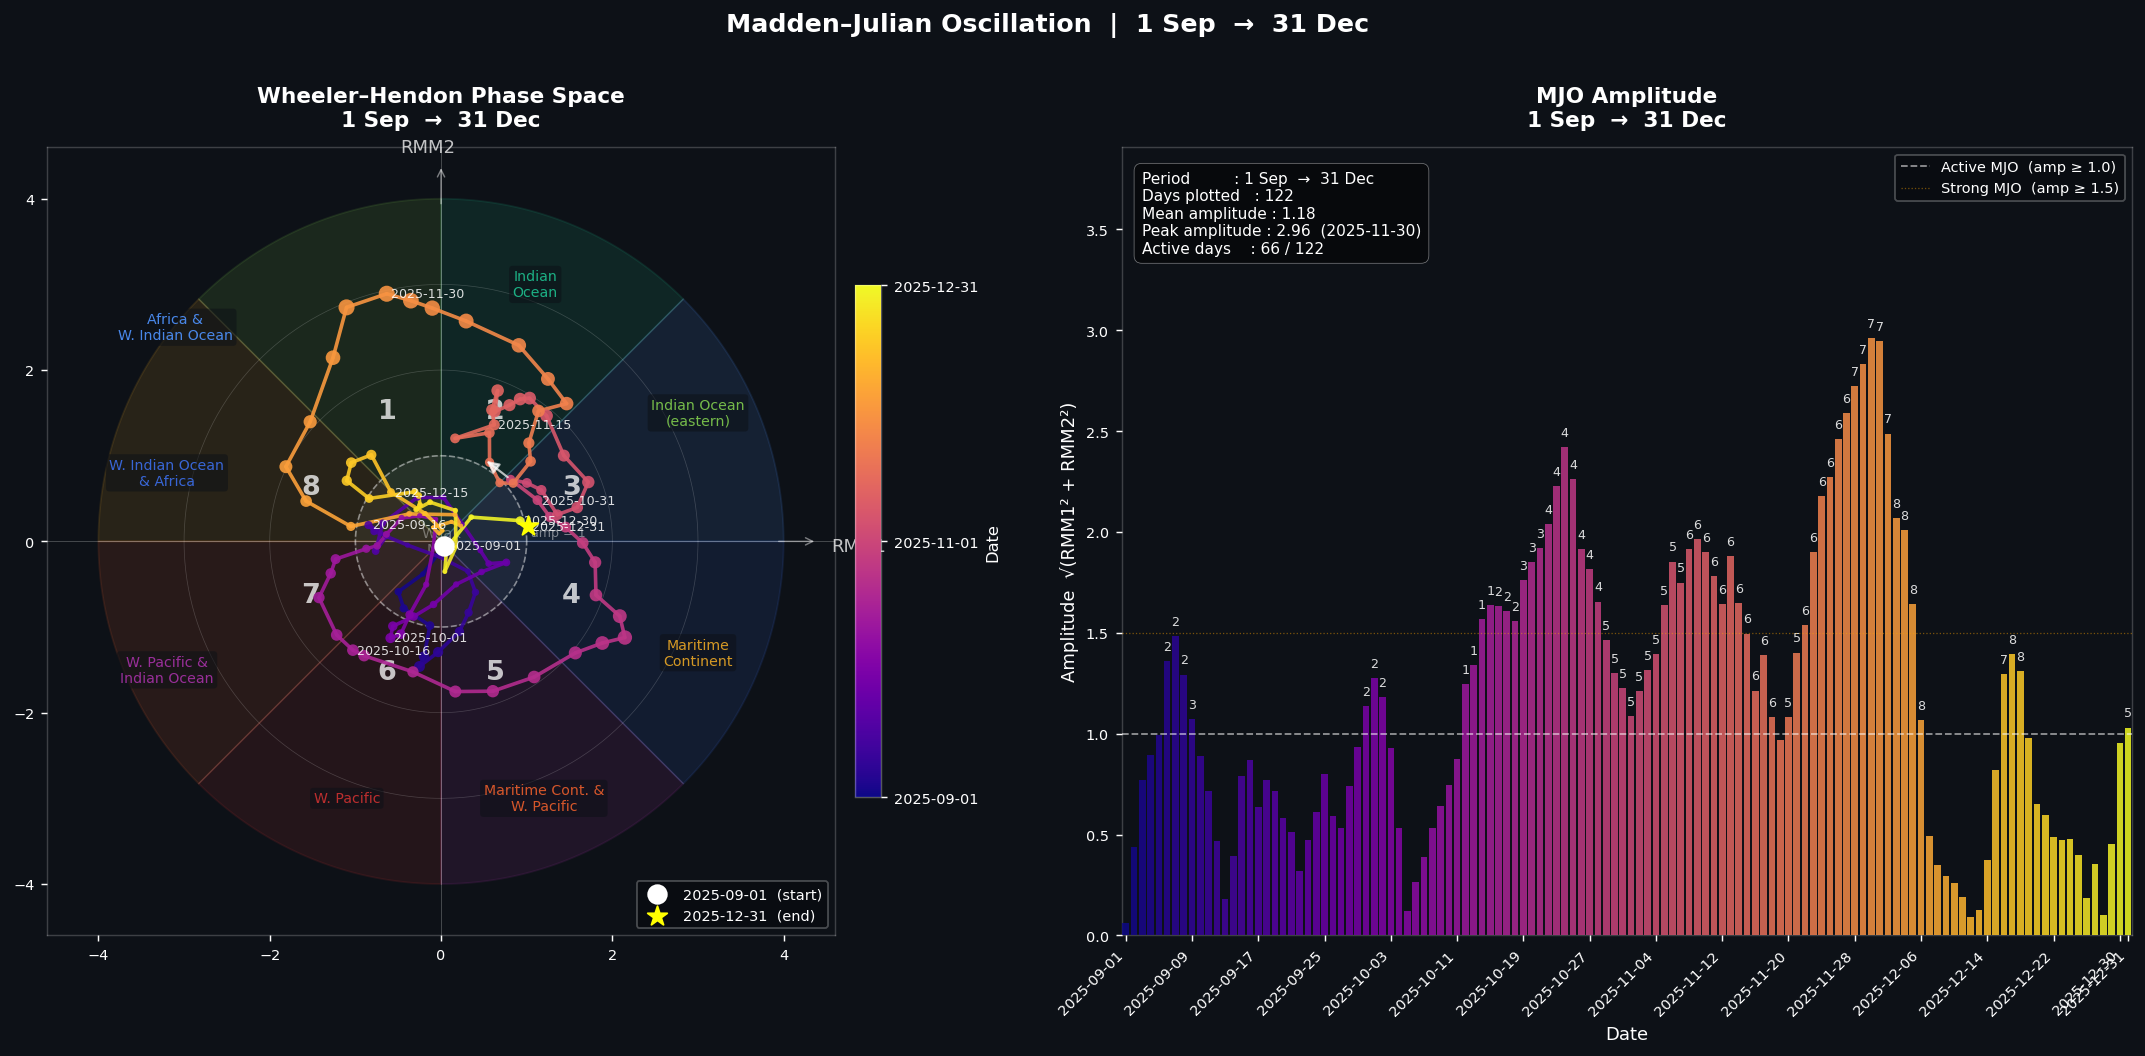

Saved → MJO_WH_20250901_20251231.png


In [12]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   Wheeler-Hendon RMM Phase Space Diagram — Custom Date Range ║
# ║   For Jupyter Notebook (.ipynb)                             ║
# ╚══════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────
# CELL 1 — Imports
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.collections import LineCollection

%matplotlib inline
plt.rcParams["figure.dpi"] = 130



# ─────────────────────────────────────────────
# CELL 2 — ✏️ SET YOUR DATE RANGE HERE
# ─────────────────────────────────────────────
CSV_PATH = "D:\PHD 2025~\PHD\MJO_Unfiltered_1980-2025.csv"   # <-- change to your file path

START_DATE = "2025-09-01"    # format: "YYYY-MM-DD"
END_DATE   = "2025-12-31"    # format: "YYYY-MM-DD"


# ─────────────────────────────────────────────
# CELL 3 — Load, Clean & Filter
# ─────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)

# Replace BOM missing value (999) with NaN
df["RMM1"]      = df["RMM1"].where(df["RMM1"].abs() < 100, np.nan)
df["RMM2"]      = df["RMM2"].where(df["RMM2"].abs() < 100, np.nan)
df["amplitude"] = df["amplitude"].where(df["amplitude"] < 100, np.nan)

# Build a proper datetime column for easy filtering
df["date"] = pd.to_datetime(df[["year", "month", "day"]])

# Parse user-supplied dates
start = pd.to_datetime(START_DATE)
end   = pd.to_datetime(END_DATE)

# Validate
if start > end:
    raise ValueError(f"START_DATE ({START_DATE}) must be before END_DATE ({END_DATE})")
if start < df["date"].min() or end > df["date"].max():
    raise ValueError(
        f"Date range {START_DATE} → {END_DATE} is outside the dataset.\n"
        f"Available range: {df['date'].min().date()} → {df['date'].max().date()}"
    )

# Filter
mask   = (df["date"] >= start) & (df["date"] <= end)
subset = df[mask].dropna(subset=["RMM1", "RMM2", "amplitude"])
subset = subset.sort_values("date").reset_index(drop=True)

# Nice date labels for each row (used in annotations)
subset["label"] = subset["date"].dt.strftime("%Y-%m-%d")   # e.g. "1 Oct"

print(f"Plotting {len(subset)} days  |  {start.date()} → {end.date()}")
print(subset[["date", "RMM1", "RMM2", "phase", "amplitude"]].to_string(index=False))


# ─────────────────────────────────────────────
# CELL 4 — Helper: WH Background
# ─────────────────────────────────────────────
def draw_wh_background(ax):
    ax.set_facecolor("#0d1117")

    sector_colors = [
        "#4C8EF5",  # Phase 1
        "#1DB88A",  # Phase 2
        "#7BC44C",  # Phase 3
        "#E0A025",  # Phase 4
        "#E05A2B",  # Phase 5
        "#C43030",  # Phase 6
        "#A030A0",  # Phase 7
        "#3A6AE0",  # Phase 8
    ]

    geo_labels = [
        ("Africa &\nW. Indian Ocean",    -3.1,  2.5),
        ("Indian\nOcean",                 1.1,  3.0),
        ("Indian Ocean\n(eastern)",       3.0,  1.5),
        ("Maritime\nContinent",           3.0, -1.3),
        ("Maritime Cont. &\nW. Pacific",  1.2, -3.0),
        ("W. Pacific",                   -1.1, -3.0),
        ("W. Pacific &\nIndian Ocean",   -3.2, -1.5),
        ("W. Indian Ocean\n& Africa",    -3.2,  0.8),
    ]

    wedge_centres_deg = [112.5, 67.5, 22.5, 337.5, 292.5, 247.5, 202.5, 157.5]
    r_outer = 4.0

    for i in range(8):
        a0 = np.radians(i * 45)
        a1 = np.radians((i + 1) * 45)
        theta   = np.linspace(a0, a1, 60)
        x_fill  = np.concatenate([[0], r_outer * np.cos(theta), [0]])
        y_fill  = np.concatenate([[0], r_outer * np.sin(theta), [0]])
        ax.fill(x_fill, y_fill, color=sector_colors[i], alpha=0.13, zorder=1)
        ax.plot([0, r_outer * np.cos(a0)],
                [0, r_outer * np.sin(a0)],
                color="white", lw=0.4, alpha=0.18, zorder=2)

        ang = np.radians(wedge_centres_deg[i])
        ax.text(1.65 * np.cos(ang), 1.65 * np.sin(ang), str(i + 1),
                color="white", fontsize=15, fontweight="bold",
                ha="center", va="center", alpha=0.75, zorder=4)

        txt, lx, ly = geo_labels[i]
        ax.text(lx, ly, txt,
                color=sector_colors[i], fontsize=7.8,
                ha="center", va="center", alpha=0.95,
                fontweight="500", zorder=4,
                bbox=dict(boxstyle="round,pad=0.25", facecolor="#0d1117",
                          alpha=0.55, edgecolor="none"))

    theta = np.linspace(0, 2 * np.pi, 360)
    ax.plot(np.cos(theta), np.sin(theta),
            color="white", lw=0.9, ls="--", alpha=0.45, zorder=3)
    ax.text(1.05, 0.06, "amp = 1", color="white", fontsize=7, alpha=0.45)
    for r in [2.0, 3.0]:
        ax.plot(r * np.cos(theta), r * np.sin(theta),
                color="white", lw=0.4, alpha=0.18, zorder=3)

    ax.add_patch(plt.Circle((0, 0), 1.0, color="white", alpha=0.05, zorder=1))
    ax.text(0, 0, "Weak\nMJO", color="white", fontsize=8, alpha=0.35,
            ha="center", va="center", zorder=3)

    ax.axhline(0, color="white", lw=0.5, alpha=0.25, zorder=2)
    ax.axvline(0, color="white", lw=0.5, alpha=0.25, zorder=2)
    ax.annotate("", xy=(4.4, 0), xytext=(3.9, 0),
                arrowprops=dict(arrowstyle="->", color="white", lw=0.8, alpha=0.45))
    ax.annotate("", xy=(0, 4.4), xytext=(0, 3.9),
                arrowprops=dict(arrowstyle="->", color="white", lw=0.8, alpha=0.45))
    ax.text( 4.55, -0.05, "RMM1", color="white", fontsize=10, va="center", alpha=0.75)
    ax.text(-0.15,  4.55, "RMM2", color="white", fontsize=10, ha="center", alpha=0.75)

    ax.set_xlim(-4.6, 4.6)
    ax.set_ylim(-4.6, 4.6)
    ax.set_aspect("equal")
    ax.tick_params(colors="white", labelsize=8)
    for spine in ax.spines.values():
        spine.set_color("white")
        spine.set_alpha(0.2)


# ─────────────────────────────────────────────
# CELL 5 — Plot
# ─────────────────────────────────────────────
rmm1   = subset["RMM1"].values
rmm2   = subset["RMM2"].values
amp    = subset["amplitude"].values
phases = subset["phase"].values
dates  = subset["date"].values          # numpy datetime64
labels = subset["label"].values         # "1 Oct", "2 Oct", ...
n      = len(subset)

# Map each row to a 0-1 value for colouring (position along the date range)
color_vals = np.linspace(0, 1, n)
cmap       = plt.cm.plasma
norm       = Normalize(vmin=0, vmax=1)

title_str  = f"{start.strftime("%d %b").lstrip("0") }  →  {end.strftime("%d %b").lstrip("0") }"

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
fig.patch.set_facecolor("#0d1117")


# ── LEFT: Phase space ────────────────────────
ax = axes[0]
draw_wh_background(ax)

# Coloured trajectory
points   = np.array([rmm1, rmm2]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
seg_cv   = (color_vals[:-1] + color_vals[1:]) / 2
lc = LineCollection(segments, cmap=cmap, norm=norm,
                    linewidth=2.0, alpha=0.9, zorder=5,
                    capstyle="round", joinstyle="round")
lc.set_array(seg_cv)
ax.add_collection(lc)

# Scatter dots (size ∝ amplitude)
ax.scatter(rmm1, rmm2,
           c=color_vals, cmap=cmap, norm=norm,
           s=(np.clip(amp, 0, 4) * 18) ** 1.1,
           zorder=6, edgecolors="none", alpha=0.9)

# ── Date annotations ──
# For short ranges (≤ 31 days): label every day
# For medium ranges (32–90 days): label every 5th day
# For long ranges (> 90 days): label every 15th day
if n <= 31:
    step = 1
elif n <= 90:
    step = 5
else:
    step = 15

for i in range(n):
    if i % step == 0 or i == n - 1:
        ax.annotate(f" {labels[i]}",
                    (rmm1[i], rmm2[i]),
                    color="white", fontsize=7, alpha=0.85,
                    va="center", zorder=7, fontweight="500")

# Start & end markers
ax.scatter(rmm1[0],  rmm2[0],  s=90,  color="white",  zorder=8,
           marker="o", edgecolors="white", linewidths=1.8,
           label=f"{labels[0]}  (start)")
ax.scatter(rmm1[-1], rmm2[-1], s=130, color="yellow", zorder=8,
           marker="*", label=f"{labels[-1]}  (end)")

# Direction arrow at midpoint
if n >= 3:
    mid = n // 2
    dx  = rmm1[mid] - rmm1[mid - 1]
    dy  = rmm2[mid] - rmm2[mid - 1]
    ax.annotate("",
                xy=(rmm1[mid] + dx, rmm2[mid] + dy),
                xytext=(rmm1[mid], rmm2[mid]),
                arrowprops=dict(arrowstyle="-|>", color="white",
                                lw=1.2, mutation_scale=14, alpha=0.7),
                zorder=9)

# Colorbar mapped to actual dates
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.65, pad=0.02)
cbar.set_label("Date", color="white", fontsize=9)
# Tick at start, middle, end
cbar.set_ticks([0, 0.5, 1.0])
cbar.set_ticklabels([labels[0], labels[n // 2], labels[-1]])
cbar.ax.yaxis.set_tick_params(color="white", labelcolor="white", labelsize=8)
cbar.outline.set_edgecolor("white")
cbar.outline.set_alpha(0.3)

ax.legend(loc="lower right", framealpha=0.25, labelcolor="white",
          fontsize=8, facecolor="black", edgecolor="white")
ax.set_title(f"Wheeler–Hendon Phase Space\n{title_str}",
             color="white", fontsize=12, fontweight="bold", pad=12)


# ── RIGHT: Amplitude time series ─────────────
ax2 = axes[1]
ax2.set_facecolor("#0d1117")

bar_colors = [cmap(norm(cv)) for cv in color_vals]
ax2.bar(range(n), amp, color=bar_colors, width=0.8, alpha=0.85, zorder=3)

# Threshold lines
ax2.axhline(1.0, color="white",  lw=1.0, ls="--", alpha=0.55, zorder=4,
            label="Active MJO  (amp ≥ 1.0)")
ax2.axhline(1.5, color="orange", lw=0.7, ls=":",  alpha=0.45, zorder=4,
            label="Strong MJO  (amp ≥ 1.5)")

# Phase number above active bars
for i, (a, ph) in enumerate(zip(amp, phases)):
    if a > 1.0 and not np.isnan(ph):
        ax2.text(i, a + 0.04, str(int(ph)),
                 ha="center", va="bottom",
                 color="white", fontsize=7, alpha=0.85)

# X-axis ticks: show dates, auto-spaced to avoid crowding
tick_step = max(1, n // 15)          # never show more than ~15 ticks
tick_idx  = list(range(0, n, tick_step))
if n - 1 not in tick_idx:
    tick_idx.append(n - 1)
ax2.set_xticks(tick_idx)
ax2.set_xticklabels([labels[i] for i in tick_idx],
                    rotation=45, ha="right", fontsize=7.5)

# Stats box
active  = int((amp > 1.0).sum())
mean_a  = amp.mean()
max_idx = np.argmax(amp)
stats   = (f"Period         : {title_str}\n"
           f"Days plotted   : {n}\n"
           f"Mean amplitude : {mean_a:.2f}\n"
           f"Peak amplitude : {amp[max_idx]:.2f}  ({labels[max_idx]})\n"
           f"Active days    : {active} / {n}")
ax2.text(0.02, 0.97, stats,
         transform=ax2.transAxes,
         color="white", fontsize=8.5, va="top",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="black",
                   alpha=0.45, edgecolor="white", linewidth=0.4))

ax2.set_xlim(-0.5, n - 0.5)
ax2.set_ylim(0, max(amp) * 1.32)
ax2.set_xlabel("Date", color="white", fontsize=10)
ax2.set_ylabel("Amplitude  √(RMM1² + RMM2²)", color="white", fontsize=10)
ax2.set_title(f"MJO Amplitude\n{title_str}",
              color="white", fontsize=12, fontweight="bold", pad=12)
ax2.tick_params(colors="white", labelsize=8)
for spine in ax2.spines.values():
    spine.set_color("white")
    spine.set_alpha(0.2)
ax2.legend(loc="upper right", framealpha=0.25, labelcolor="white",
           fontsize=8, facecolor="black", edgecolor="white")

fig.suptitle(f"Madden–Julian Oscillation  |  {title_str}",
             color="white", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()

fname = f"MJO_WH_{start.strftime('%Y%m%d')}_{end.strftime('%Y%m%d')}.png"
plt.savefig(fname, dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print(f"Saved → {fname}")